In [1]:
# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

import contextily as ctx

In [35]:
# Prepare data

df = pd.read_csv("/content/drive/MyDrive/Oman_DT/Oman_2022_2025_MAR_UHI_FINAL.csv")
# Features
features = ['NDWI','soil_moist','precip','NDBI','NDVI','temp_air','wind_speed']

# Drop NaNs just in case
df = df.dropna(subset=features + ['LST']).copy()

X = df[features]
y = df['LST']   # NO scaling

In [4]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
# Spatial split instead of random train-test split
unique_hex = df['hex_id'].unique()

train_hex, test_hex = train_test_split(unique_hex, test_size=0.2, random_state=42)

train_idx = df['hex_id'].isin(train_hex)
test_idx  = df['hex_id'].isin(test_hex)

X_train = df.loc[train_idx, features]
X_test  = df.loc[test_idx, features]
y_train = df.loc[train_idx, 'LST']
y_test  = df.loc[test_idx, 'LST']

In [37]:
# Scaling
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame (important for feature names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=features)

In [38]:
# Train the model
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [7]:
# Evaluate the model
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1.552613067921463


In [39]:
# Evaluate the model on spatial train-test dataset
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1.8728233125970744


In [8]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

NDWI          0.297946
temp_air      0.279912
NDVI          0.142696
NDBI          0.132439
precip        0.058362
soil_moist    0.047741
wind_speed    0.040904
dtype: float32


In [40]:
# Feature importance (with spatial split)
importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

temp_air      0.295081
NDWI          0.281668
NDVI          0.144106
NDBI          0.128300
precip        0.060293
soil_moist    0.046005
wind_speed    0.044547
dtype: float32


Surface wetness (NDWI) emerges as the most influential predictor of land surface temperature, exceeding both vegetation and built-up effects, even under spatial generalization constraints.

The cooling effect of wetness is not just local—it is spatially consistent across Oman.

Feature importance analysis indicates that surface wetness (NDWI) is the dominant predictor of land surface temperature, followed closely by ambient air temperature. Vegetation and built-up indices contribute secondary effects, while precipitation, soil moisture, and wind speed play relatively minor roles at the monthly scale.

#### DIGITAL TWIN SIMULATION

In [66]:
# Scale FULL dataset using TRAIN scaler
X_all_scaled = scaler.transform(df[features])
X_all_scaled = pd.DataFrame(X_all_scaled, columns=features)

In [67]:
# Baseline prediction
df['LST_pred'] = model.predict(X_all_scaled)

In [68]:
# Targeted intervention
df_sim = X_all_scaled.copy()

# Define hotspot + dry mask
mask = (
    (df['LST'] > df['LST'].quantile(0.7)) &
    (df['NDWI'] < 0.4)
)

# Apply intervention ONLY where needed
df_sim.loc[mask, 'NDWI'] += 0.1
df_sim.loc[mask, 'NDVI'] += 0.05
df_sim.loc[mask, 'NDBI'] -= 0.05

# Keep within bounds
df_sim = df_sim.clip(0, 1)

In [69]:
# Predict new temp
df['LST_new'] = model.predict(df_sim)

In [70]:
# Compute cooling
df['Cooling'] = df['LST_pred'] - df['LST_new']

In [46]:
# Summary
print(df['Cooling'].describe())

print("Mean cooling:", df['Cooling'].mean())
print("P90 cooling:", df['Cooling'].quantile(0.9))

count    497952.000000
mean          1.948055
std           3.189533
min          -2.954323
25%           0.000000
50%           0.000000
75%           4.610920
max          15.255653
Name: Cooling, dtype: float64
Mean cooling: 1.9480551
P90 cooling: 7.392351531982422


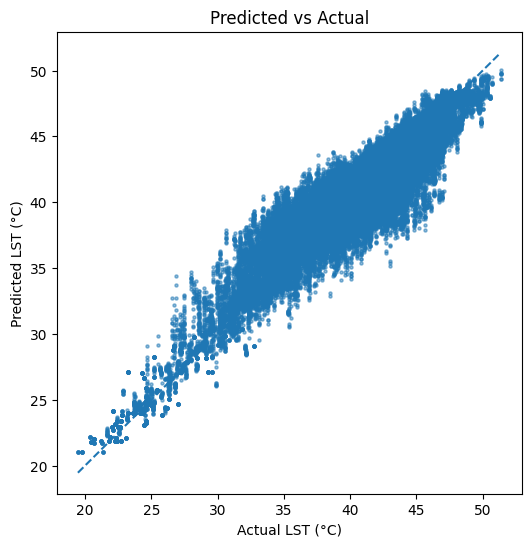

In [16]:
# Plots
# Predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, s=5, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual LST (°C)")
plt.ylabel("Predicted LST (°C)")
plt.title("Predicted vs Actual")

plt.show()

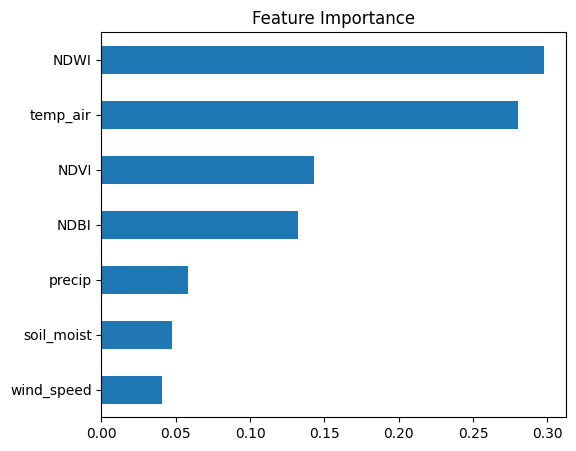

In [17]:
# Feature imp
importance.sort_values().plot(kind='barh', figsize=(6,5))
plt.title("Feature Importance")
plt.show()

In [71]:
!pip install shap -q
import shap

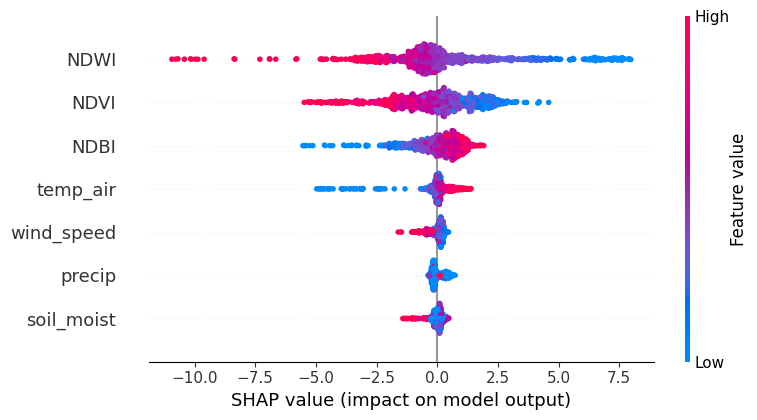

In [74]:
sample = X_test_scaled.sample(1000, random_state=42)

explainer = shap.Explainer(model)
shap_values = explainer(sample)

shap.summary_plot(shap_values, sample)

SHAP analysis confirms that increased surface wetness (NDWI) consistently contributes to lower land surface temperatures, reinforcing its dominant role in urban thermal regulation.

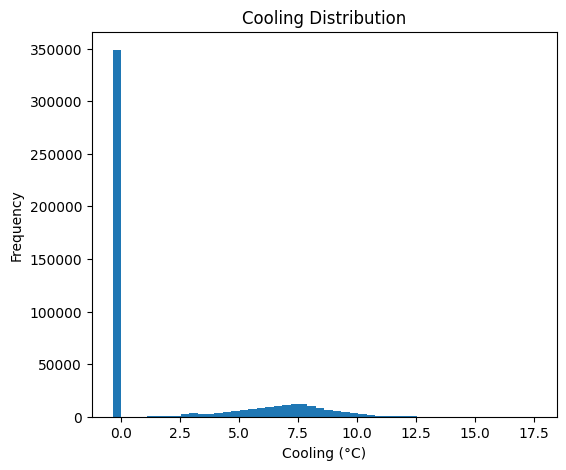

In [18]:
# Cooling distribution
plt.figure(figsize=(6,5))
plt.hist(df['Cooling'], bins=50)

plt.xlabel("Cooling (°C)")
plt.ylabel("Frequency")
plt.title("Cooling Distribution")

plt.show()

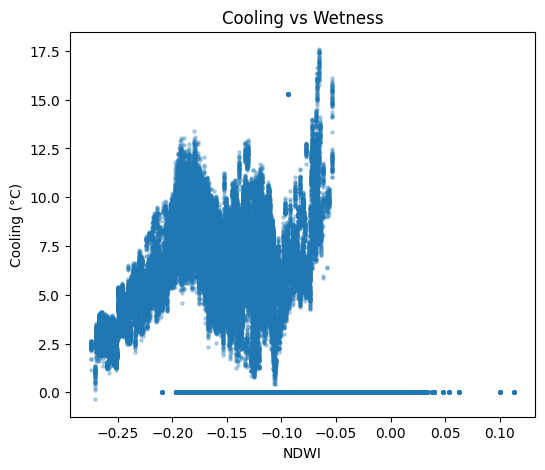

In [19]:
# Cooling vs NDBI
plt.figure(figsize=(6,5))
plt.scatter(df['NDWI'], df['Cooling'], s=5, alpha=0.3)

plt.xlabel("NDWI")
plt.ylabel("Cooling (°C)")
plt.title("Cooling vs Wetness")

plt.show()

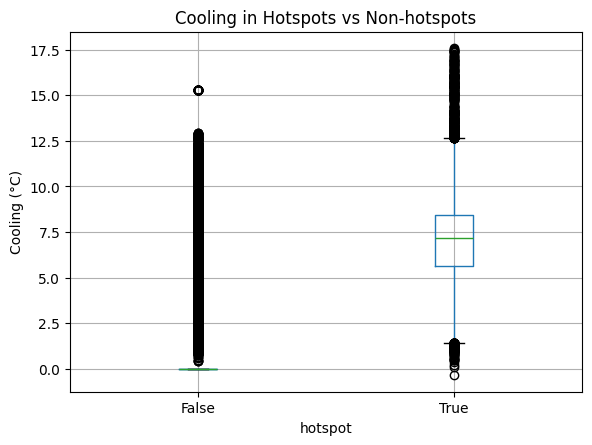

In [20]:
# Hotspot vs non-hotspots
df['hotspot'] = df['LST'] > df['LST'].quantile(0.8)

df.boxplot(column='Cooling', by='hotspot')

plt.title("Cooling in Hotspots vs Non-hotspots")
plt.suptitle("")
plt.ylabel("Cooling (°C)")

plt.show()

In [21]:
# test multiple NDWI increases and pick the best one
# Prepare baseline
X_all_scaled = scaler.transform(df[features])
X_all_scaled = pd.DataFrame(X_all_scaled, columns=features)

df['LST_pred'] = model.predict(X_all_scaled)

In [22]:
# Define candidate interventions
ndwi_steps = [0.02, 0.05, 0.1, 0.15, 0.2]

In [23]:
# Run simulation loop
results = []

for step in ndwi_steps:

    X_sim = X_all_scaled.copy()

    # Apply ONLY to hotspots + dry areas
    mask = (
        (df['LST'] > df['LST'].quantile(0.7)) &
        (df['NDWI'] < 0.4)
    )

    X_sim.loc[mask, 'NDWI'] += step
    X_sim.loc[mask, 'NDVI'] += step * 0.5
    X_sim.loc[mask, 'NDBI'] -= step * 0.5

    X_sim = X_sim.clip(0,1)

    LST_new = model.predict(X_sim)

    cooling = df['LST_pred'] - LST_new

    results.append({
        'step': step,
        'mean_cooling': cooling.mean(),
        'p90_cooling': np.quantile(cooling, 0.9)
    })

In [24]:
# Analyze results
results_df = pd.DataFrame(results)
print(results_df)

   step  mean_cooling  p90_cooling
0  0.02      0.437976     1.784525
1  0.05      1.148193     4.639019
2  0.10      2.078871     7.806831
3  0.15      2.835832    10.242188
4  0.20      3.652243    13.419968


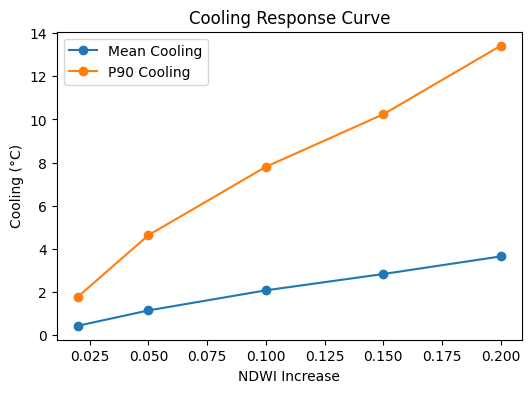

In [25]:
# Plot response curve
plt.figure(figsize=(6,4))

plt.plot(results_df['step'], results_df['mean_cooling'], marker='o')
plt.plot(results_df['step'], results_df['p90_cooling'], marker='o')

plt.xlabel("NDWI Increase")
plt.ylabel("Cooling (°C)")
plt.title("Cooling Response Curve")

plt.legend(["Mean Cooling", "P90 Cooling"])
plt.show()

In [26]:
# Pick potential interventions
optimal_step = results_df.loc[
    results_df['mean_cooling'].idxmax(), 'step'
]

In [27]:
# Apply simulation
X_sim_final = X_all_scaled.copy()

mask = (
    (df['LST'] > df['LST'].quantile(0.7)) &
    (df['NDWI'] < 0.4)
)

X_sim_final.loc[mask, 'NDWI'] += optimal_step
X_sim_final.loc[mask, 'NDVI'] += optimal_step * 0.5
X_sim_final.loc[mask, 'NDBI'] -= optimal_step * 0.5

X_sim_final = X_sim_final.clip(0,1)

df['LST_new'] = model.predict(X_sim_final)
df['Cooling'] = df['LST_pred'] - df['LST_new']

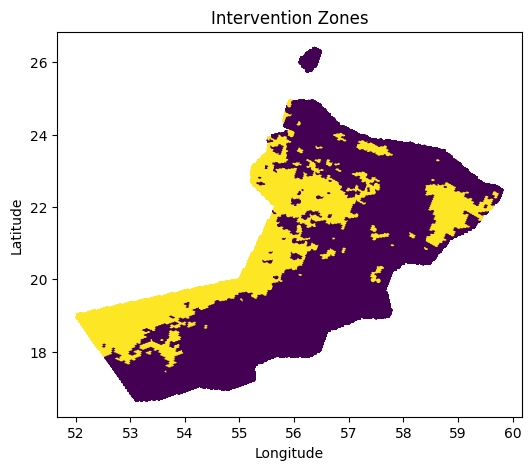

In [28]:
# Plot
# Map: Where intervention happened
df['intervention'] = mask.astype(int)

plt.figure(figsize=(6,5))
plt.scatter(df['lon'], df['lat'],
            c=df['intervention'],
            s=5)

plt.title("Intervention Zones")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

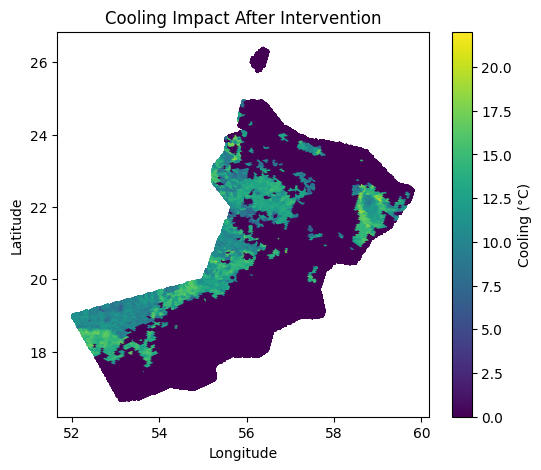

In [29]:
# Cooling map
plt.figure(figsize=(6,5))

plt.scatter(
    df['lon'],
    df['lat'],
    c=df['Cooling'],
    s=5
)

plt.colorbar(label='Cooling (°C)')
plt.title("Cooling Impact After Intervention")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

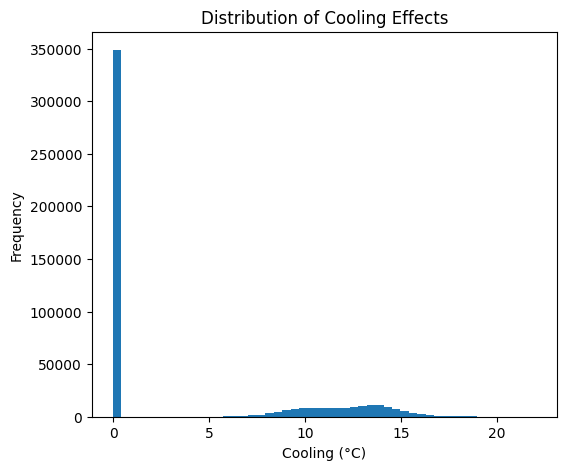

In [30]:
# Cooling distribution
plt.figure(figsize=(6,5))

plt.hist(df['Cooling'], bins=50)

plt.xlabel("Cooling (°C)")
plt.ylabel("Frequency")
plt.title("Distribution of Cooling Effects")

plt.show()

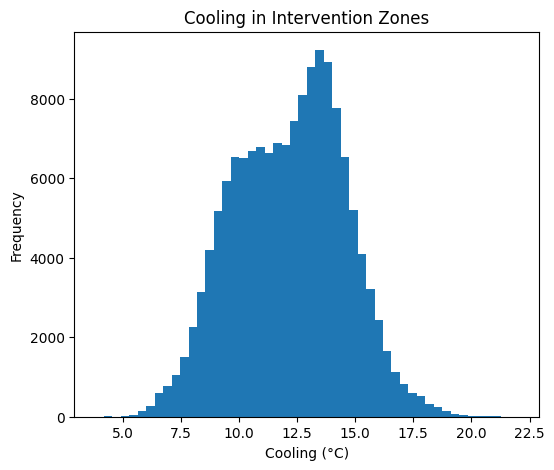

In [31]:
# Cooling only in intervention zones
plt.figure(figsize=(6,5))

plt.hist(df.loc[df['intervention']==1, 'Cooling'], bins=50)

plt.xlabel("Cooling (°C)")
plt.ylabel("Frequency")
plt.title("Cooling in Intervention Zones")

plt.show()

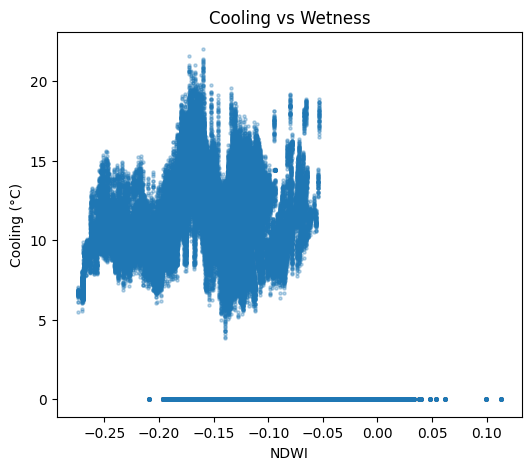

In [32]:
# Cooling vs NDWI
plt.figure(figsize=(6,5))

plt.scatter(df['NDWI'], df['Cooling'], s=5, alpha=0.3)

plt.xlabel("NDWI")
plt.ylabel("Cooling (°C)")
plt.title("Cooling vs Wetness")

plt.show()

/tmp/ipykernel_5823/444493250.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask, 'NDWI_change'] = optimal_step


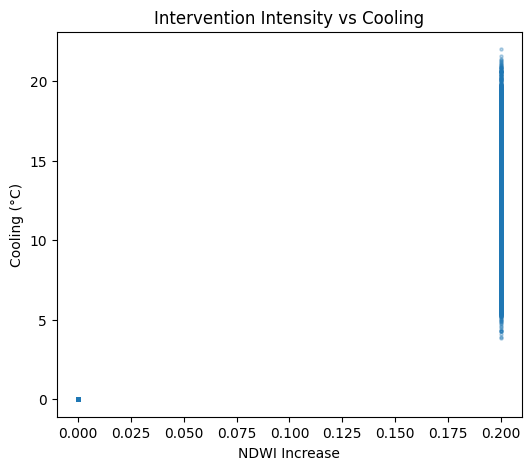

In [33]:
# Intervention intensity vs cooling
df['NDWI_change'] = 0
df.loc[mask, 'NDWI_change'] = optimal_step

plt.figure(figsize=(6,5))

plt.scatter(df['NDWI_change'], df['Cooling'], s=5, alpha=0.3)

plt.xlabel("NDWI Increase")
plt.ylabel("Cooling (°C)")
plt.title("Intervention Intensity vs Cooling")

plt.show()

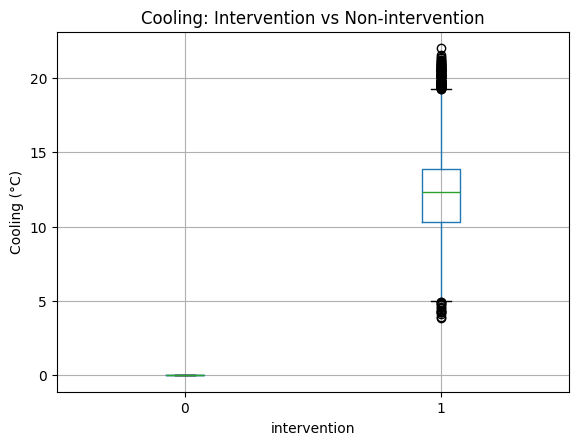

In [34]:
# Box plot
df.boxplot(column='Cooling', by='intervention')

plt.title("Cooling: Intervention vs Non-intervention")
plt.suptitle("")
plt.ylabel("Cooling (°C)")

plt.show()

Plots
(a) Cooling potential
(b) UHI hotspots
(c) Combined MAR + Cooling priority

In [48]:
! pip install h3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.9 MB/s eta 0:00:00


In [51]:
! pip install contextily -q

In [52]:
import geopandas as gpd
from shapely.geometry import Polygon
import h3
import matplotlib.pyplot as plt
import contextily as ctx

In [53]:
# Fix geometry

def hex_to_polygon(hex_id):
    boundary = h3.cell_to_boundary(hex_id)
    return Polygon([(lng, lat) for lat, lng in boundary])

df_hex = df.copy()
df_hex['geometry'] = df_hex['hex_id'].apply(hex_to_polygon)

gdf = gpd.GeoDataFrame(df_hex, geometry='geometry', crs="EPSG:4326")

# Project for correct map rendering
gdf = gdf.to_crs(epsg=3857)

In [54]:
# Prepare variables
# Cooling already computed
# df['Cooling']

# Hotspots (top 20%)
gdf['hotspot'] = gdf['LST'] > gdf['LST'].quantile(0.8)

# Normalize MAR score
gdf['MAR_norm'] = (gdf['MAR_score'] - gdf['MAR_score'].min()) / (
    gdf['MAR_score'].max() - gdf['MAR_score'].min()
)

# Normalize cooling
gdf['Cooling_norm'] = (gdf['Cooling'] - gdf['Cooling'].min()) / (
    gdf['Cooling'].max() - gdf['Cooling'].min()
)

# Combined priority
gdf['priority'] = 0.5 * gdf['Cooling_norm'] + 0.5 * gdf['MAR_norm']

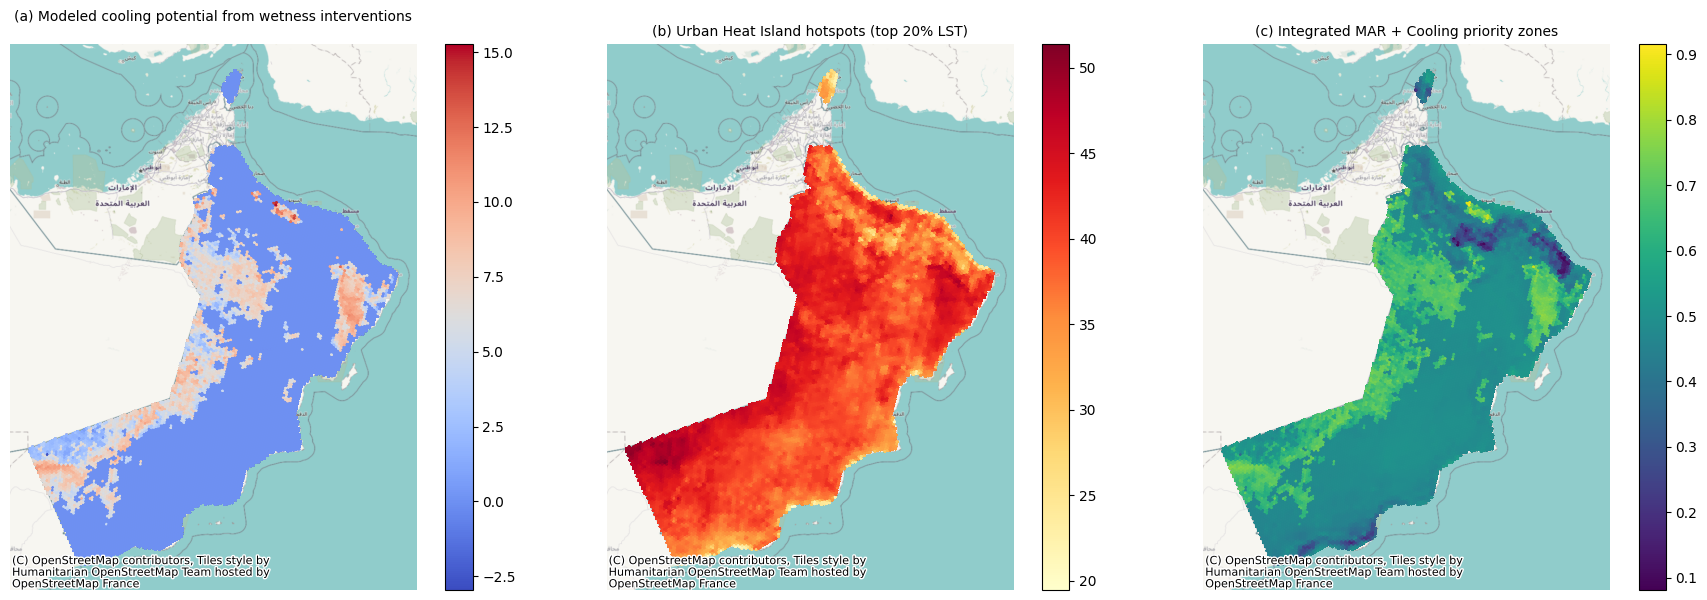

In [55]:
# Build multi-panel figure

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


# (a) Cooling Map

gdf.plot(
    column='Cooling',
    cmap='coolwarm',
    linewidth=0,
    ax=axes[0],
    legend=True
)

ctx.add_basemap(axes[0])

axes[0].set_title("(a) Modeled cooling potential from wetness interventions", fontsize=10)
axes[0].set_axis_off()


# (b) Hotspot Map

gdf.plot(
    column='LST',
    cmap='YlOrRd',
    linewidth=0,
    ax=axes[1],
    legend=True
)

ctx.add_basemap(axes[1])

axes[1].set_title("(b) Urban Heat Island hotspots (top 20% LST)", fontsize=10)
axes[1].set_axis_off()


# (c) Combined Priority Map

gdf.plot(
    column='priority',
    cmap='viridis',
    linewidth=0,
    ax=axes[2],
    legend=True
)

ctx.add_basemap(axes[2])

axes[2].set_title("(c) Integrated MAR + Cooling priority zones", fontsize=10)
axes[2].set_axis_off()

plt.tight_layout()

# Save publication-quality figure
plt.savefig("Figure_1_Final.png", dpi=300, bbox_inches='tight')

plt.show()

Figure (a) Modeled cooling potential resulting from targeted wetness and vegetation interventions. (b) Urban Heat Island (UHI) hotspots identified using the upper 20th percentile of land surface temperature. (c) Integrated prioritization of intervention zones combining thermal mitigation and managed aquifer recharge (MAR) suitability.

<Axes: >

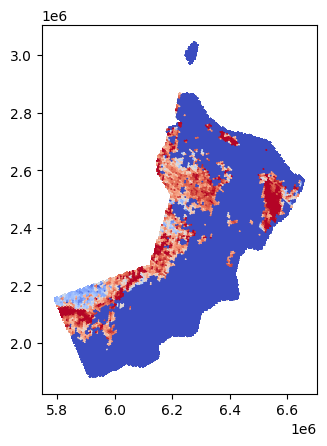

In [56]:
# Fix color consistency
vmin = gdf['Cooling'].quantile(0.05)
vmax = gdf['Cooling'].quantile(0.95)

# Prevents extreme values from distorting colors
gdf.plot(column='Cooling', cmap='coolwarm', vmin=vmin, vmax=vmax)

#### Ensemble-based uncertainty

Train multiple models and measure how much predictions vary.

In [57]:
# Train mu,tiple models
n_models = 5
models = []

for i in range(n_models):

    m = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=i   # different seed
    )

    m.fit(X_train_scaled, y_train)
    models.append(m)

In [58]:
# Predict baseline (all models)
preds_base = []

for m in models:
    preds_base.append(m.predict(X_all_scaled))

preds_base = np.array(preds_base)

In [59]:
# Predict intervention scenario
preds_new = []

for m in models:
    preds_new.append(m.predict(X_sim_final))

preds_new = np.array(preds_new)

In [60]:
# Compute cooling for each model
cooling_ensemble = preds_base - preds_new

In [61]:
# Compute uncertainty
df['Cooling_mean'] = cooling_ensemble.mean(axis=0)
df['Cooling_std']  = cooling_ensemble.std(axis=0)

In [62]:
# Add to geodataframe
gdf['Cooling_mean'] = df['Cooling_mean']
gdf['Cooling_std']  = df['Cooling_std']

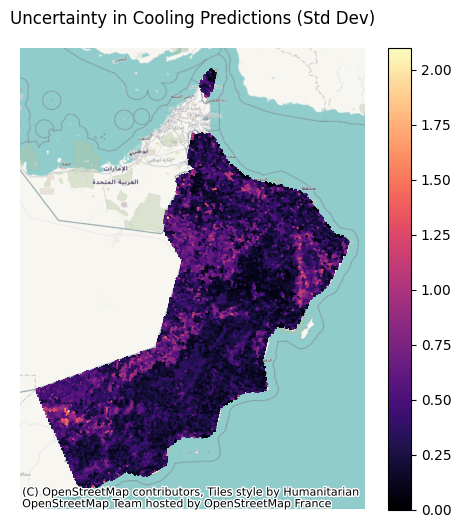

In [63]:
# Plot uncertainty map
fig, ax = plt.subplots(1, 1, figsize=(6,6))

gdf.plot(
    column='Cooling_std',
    cmap='magma',
    linewidth=0,
    legend=True,
    ax=ax
)

import contextily as ctx
ctx.add_basemap(ax)

ax.set_title("Uncertainty in Cooling Predictions (Std Dev)")
ax.set_axis_off()

plt.show()

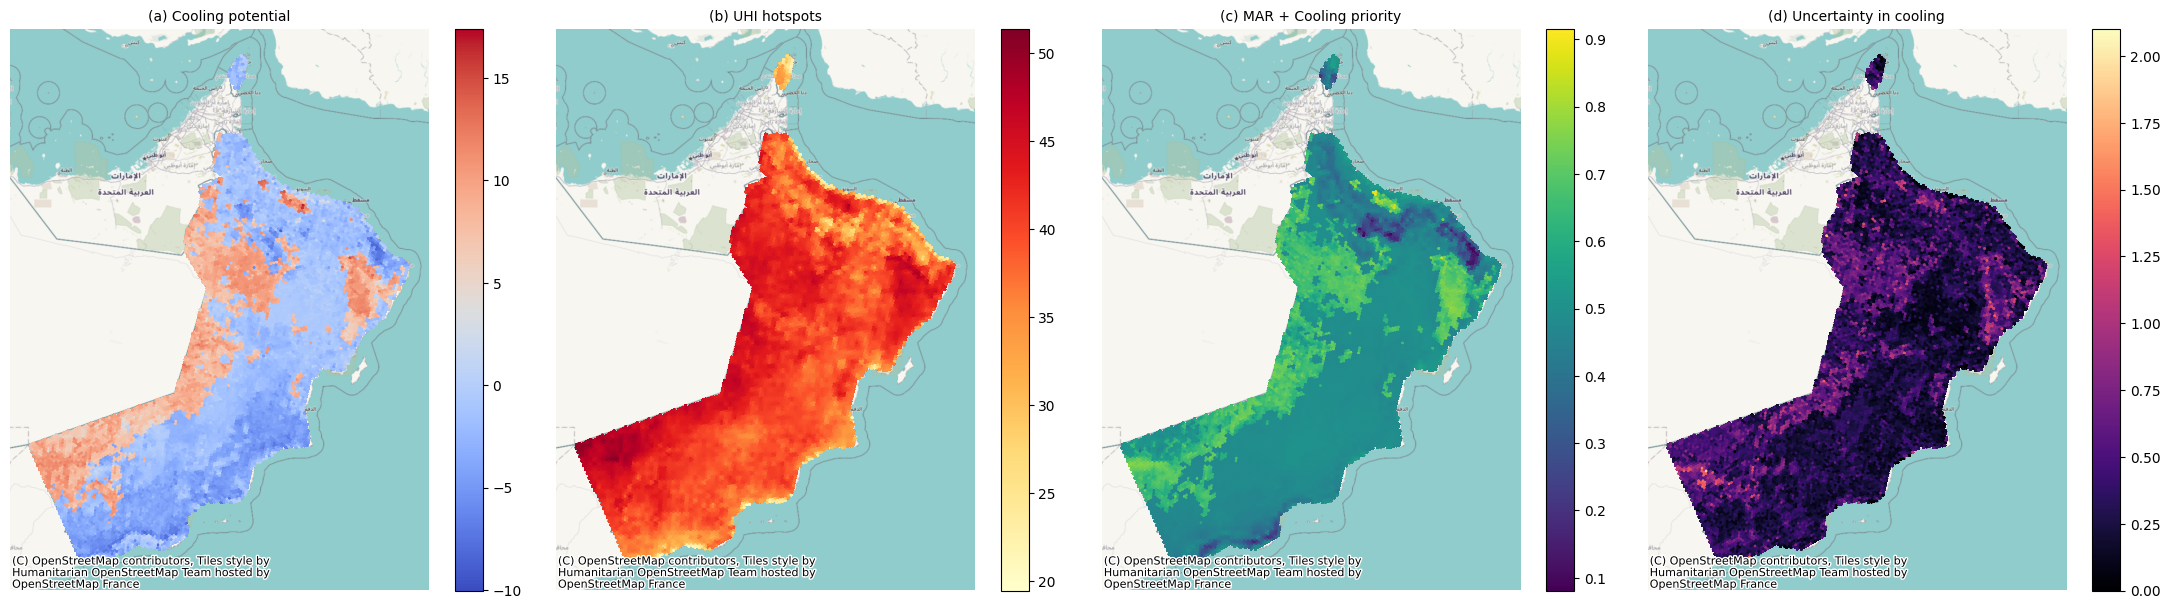

In [65]:
# Plots

fig, axes = plt.subplots(1, 4, figsize=(22, 6))


# (a) Cooling Map

gdf.plot(
    column='Cooling_mean',
    cmap='coolwarm',
    linewidth=0,
    ax=axes[0],
    legend=True
)
ctx.add_basemap(axes[0])
axes[0].set_title("(a) Cooling potential", fontsize=10)
axes[0].set_axis_off()



# (b) Hotspot Map

gdf.plot(
    column='LST',
    cmap='YlOrRd',
    linewidth=0,
    ax=axes[1],
    legend=True
)
ctx.add_basemap(axes[1])
axes[1].set_title("(b) UHI hotspots", fontsize=10)
axes[1].set_axis_off()



# (c) Priority Map

gdf.plot(
    column='priority',
    cmap='viridis',
    linewidth=0,
    ax=axes[2],
    legend=True
)
ctx.add_basemap(axes[2])
axes[2].set_title("(c) MAR + Cooling priority", fontsize=10)
axes[2].set_axis_off()



# (d) Uncertainty Map

gdf.plot(
    column='Cooling_std',
    cmap='magma',
    linewidth=0,
    ax=axes[3],
    legend=True
)
ctx.add_basemap(axes[3])
axes[3].set_title("(d) Uncertainty in cooling", fontsize=10)
axes[3].set_axis_off()


plt.tight_layout()

plt.savefig("Figure_Final_4panel.png", dpi=300, bbox_inches='tight')

plt.show()

🔷 Low uncertainty

* Model confident
* Results reliable

🔷 High uncertainty

* Possible reasons:

-sparse data

-extreme values

-conflicting signals

Prediction uncertainty was quantified using an ensemble of XGBoost models with varying initialization. The standard deviation of predicted cooling across the ensemble was used as a proxy for model uncertainty. Results indicate higher uncertainty in regions with extreme environmental conditions and lower data support.